# Fine-tuning BETO para Deteccion de Discurso de Odio (HatEval-ES)
## Proyecto Final -- Deep Learning

> **Objetivo y contexto**
>
> Este notebook evalua si el *fine-tuning* supervisado de BETO con una senal de clasificacion reorganiza su espacio de embeddings de forma mas util que BETO sin ajustar, usando **HatEval-ES** (SemEval-2019 Task 5): 6,599 tweets en espanol etiquetados binariamente como `HS=1` (contiene discurso de odio hacia mujeres o inmigrantes) o `HS=0`.
>
> El *ablation study* de congelamiento progresivo de capas esta motivado por la razon entre parametros entrenables y ejemplos de entrenamiento: con el modelo completo descongelado (109M de parametros) sobre ~4,600 ejemplos de entrenamiento, esa razon es de aproximadamente 23,600 parametros por ejemplo.
>
> Se usa **solo `HS`** (Task A del *shared task*) -- las subtareas `TR` (target individual/grupal) y `AG` (agresividad) solo estan definidas para tweets ya odiosos y responden una pregunta mas fina que no es el objetivo de este trabajo; se documentan como posible extension futura, no se implementan aqui.

## Library Imports

In [1]:
import os
os.environ["HF_TOKEN"] = ""

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import BertTokenizerFast as BertTokenizer, BertModel, get_linear_schedule_with_warmup

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score, accuracy_score
from sklearn.manifold import TSNE

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt

In [2]:
!pip install --quiet pyarrow==17.0.0 datasets==3.0.0

In [3]:
!nvidia-smi --query-gpu=index,memory.used,memory.total,memory.free --format=csv

index, memory.used [MiB], memory.total [MiB], memory.free [MiB]
0, 141793 MiB, 143771 MiB, 1375 MiB
1, 11422 MiB, 143771 MiB, 131746 MiB
2, 533 MiB, 143771 MiB, 142634 MiB
3, 5633 MiB, 143771 MiB, 137534 MiB
4, 143135 MiB, 143771 MiB, 33 MiB
5, 143135 MiB, 143771 MiB, 33 MiB
6, 138073 MiB, 143771 MiB, 5095 MiB
7, 35104 MiB, 143771 MiB, 108064 MiB


In [4]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

RANDOM_SEED = 43

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
rcParams['figure.figsize'] = 8, 6

pl.seed_everything(RANDOM_SEED)

INFO:lightning_fabric.utilities.seed:Seed set to 43


43

## 1. Configuracion

### Autenticacion con Hugging Face (dataset gated)

In [5]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

**HatEval-ES es un dataset *gated* en Hugging Face** -- necesitas aceptar los terminos de acceso con tu propia cuenta antes de poder descargarlo desde codigo:

1. Entra a https://huggingface.co/datasets/valeriobasile/HatEval con tu cuenta de Hugging Face.
2. Click en "Agree and access repository".
3. Genera un token de acceso (Settings -> Access Tokens -> New token, con permiso de lectura) si no tienes uno.
4. En Colab, agrega ese token como Secret (panel de la llave 🔑) con nombre `HF_TOKEN`, y activa "Notebook access" -- exactamente el mismo mecanismo que usaste con `KAGGLE_KEY` en el proyecto de IMDB.

El dataset viene en formato Parquet y es **multilingue** (19,600 tweets totales: 13,000 en, 6,600 es) -- se filtra por `lang == "es"` despues de cargarlo completo, verificando primero que la columna existe con ese nombre exacto (no asumido).

In [6]:
CONFIG = {
    "HF_DATASET_ID": "valeriobasile/HatEval",
    "LANG_FILTER":   "es",
    "BERT_MODEL":    "dccuchile/bert-base-spanish-wwm-cased",
    "RANDOM_STATE":  RANDOM_SEED,
    "TRAIN_FRAC":    0.70,
    "VAL_FRAC":      0.15,
    "TEST_FRAC":     0.15,
    "BATCH_SIZE":    64,
    "N_EPOCHS_ABLATION": 12,
    "PATIENCE_ABLATION": 2,
    "UNFROZEN_PCTS": [0, 25, 50, 75, 100],
    "CV_REPEATS":    5,
    "CV_FOLDS":      5,
    "EMBEDDINGS_DIR": Path("embeddings_beto_hateval"),
    "LOGS_DIR":       Path("logs-beto-hateval-ablation"),
}

CONFIG["EMBEDDINGS_DIR"].mkdir(exist_ok=True)
CONFIG["LOGS_DIR"].mkdir(exist_ok=True)

## 2. Carga y exploracion de datos

In [7]:
from datasets import load_dataset

hf_dataset = load_dataset(CONFIG["HF_DATASET_ID"])

print("Splits disponibles:", list(hf_dataset.keys()))
print("Columnas:", hf_dataset[list(hf_dataset.keys())[0]].column_names)

dfs = []
for split_name, split_data in hf_dataset.items():
    part = split_data.to_pandas()
    part["source_split"] = split_name
    dfs.append(part)
    print(f"{split_name}: {len(part)} filas")

df = pd.concat(dfs, ignore_index=True)
print("\nTotal combinado (todos los idiomas):", len(df))

if "language" in df.columns:
    print("Distribucion de idiomas:\n", df["language"].value_counts())
    df = df[df["language"] == CONFIG["LANG_FILTER"]].reset_index(drop=True)
    print(f"\nTras filtrar language == '{CONFIG['LANG_FILTER']}':", len(df))

df.head(3)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Splits disponibles: ['train', 'dev', 'test']
Columnas: ['id', 'text', 'target', 'language', 'HS', 'TR', 'AG', '__index_level_0__']
train: 13500 filas
dev: 1500 filas
test: 4570 filas

Total combinado (todos los idiomas): 19570
Distribucion de idiomas:
 language
en    12971
es     6599
Name: count, dtype: int64

Tras filtrar language == 'es': 6599


,id,text,target,language,HS,TR,AG,__index_level_0__,source_split
0,20001,Easyjet quiere duplicar el número de mujeres p...,mis,es,1,0,0,12971,train
1,20002,El gobierno debe crear un control estricto de ...,mig,es,1,0,0,12972,train
2,20003,Yo veo a mujeres destruidas por acoso laboral ...,mis,es,0,0,0,12973,train


**Exploracion de datos**: nulos, duplicados por `id`, y distribucion de `HS` -- confirmar el balance real antes de decidir si hace falta `class_weight`.

In [8]:
print("Nulos por columna:\n", df.isnull().sum())
print("\nid duplicados:", df["id"].duplicated().sum())
print("\nDistribucion de HS:\n", df["HS"].value_counts(normalize=True).round(3))

Nulos por columna:
 id                   0
text                 0
target               0
language             0
HS                   0
TR                   0
AG                   0
__index_level_0__    0
source_split         0
dtype: int64

id duplicados: 0

Distribucion de HS:
 HS
0    0.585
1    0.415
Name: proportion, dtype: float64


Registros finales tras deduplicar/limpiar: 6599


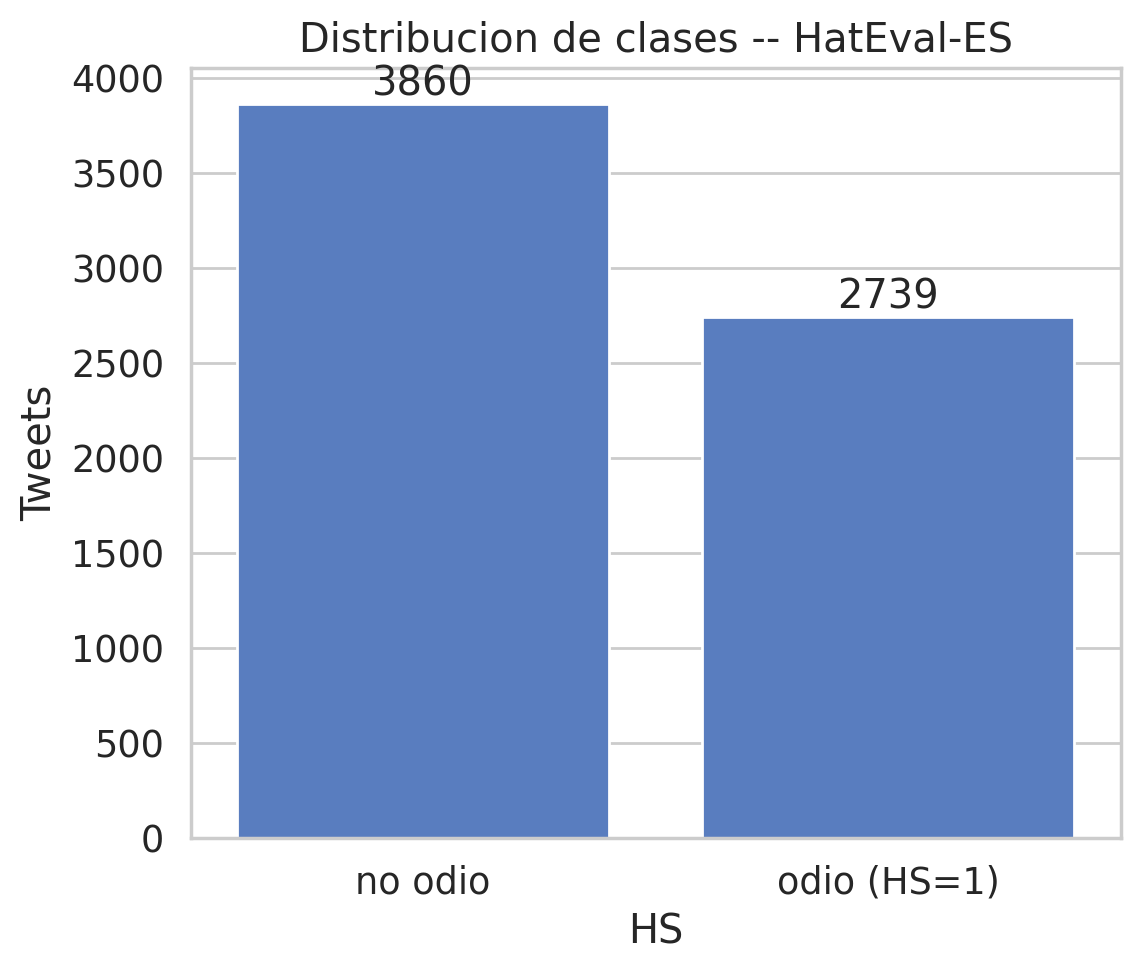

In [9]:
df = df.drop_duplicates(subset="id").reset_index(drop=True)
df = df.dropna(subset=["text", "HS"]).reset_index(drop=True)
df["HS"] = df["HS"].astype(int)

print("Registros finales tras deduplicar/limpiar:", len(df))

fig, ax = plt.subplots(figsize=(6, 5))
counts = df["HS"].value_counts().rename({0: "no odio", 1: "odio (HS=1)"})
sns.barplot(x=counts.index, y=counts.values, ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title("Distribucion de clases -- HatEval-ES")
ax.set_ylabel("Tweets")
plt.show()

### Sobre el desbalance de clases

A diferencia de IMDB, HatEval no viene perfectamente balanceado por diseno (la proporcion real de odio suele rondar 40-45% segun la edicion del dataset) -- se confirma con la celda anterior. Se usa `class_weight`/`weight` tanto en el fine-tuning de BETO (`CrossEntropyLoss(weight=...)`) como en los clasificadores clasicos (`class_weight="balanced"`).

## 3. Division train / validation / test (70 / 15 / 15)

Con 6,599 ejemplos, el `val` set resultante (~990 ejemplos) es lo suficientemente grande para que la seleccion de la mejor configuracion del *ablation* no dependa del ruido de muestreo de una particion de validacion chica.

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=(1 - CONFIG["TRAIN_FRAC"]),
    stratify=df["HS"],
    random_state=CONFIG["RANDOM_STATE"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=CONFIG["TEST_FRAC"] / (CONFIG["TEST_FRAC"] + CONFIG["VAL_FRAC"]),
    stratify=temp_df["HS"],
    random_state=CONFIG["RANDOM_STATE"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name} -- HS=1: {split['HS'].mean():.3f}")

Train: 4619 | Val: 990 | Test: 990
  Train -- HS=1: 0.415
  Val -- HS=1: 0.415
  Test -- HS=1: 0.415


## 4. Tokenizacion y longitud de secuencia

In [11]:
tokenizer = BertTokenizer.from_pretrained(CONFIG["BERT_MODEL"])

**Analisis de longitud de tokens -- calculado sobre los datos reales.** Los tweets tienen un limite de caracteres nativo de Twitter, asi que se espera un `MAX_TOKEN_COUNT` bastante menor que en IMDB -- se verifica, no se asume.

Min: 5 | Max: 340 | Media: 41.66767698636068
Percentil 95: 81.0


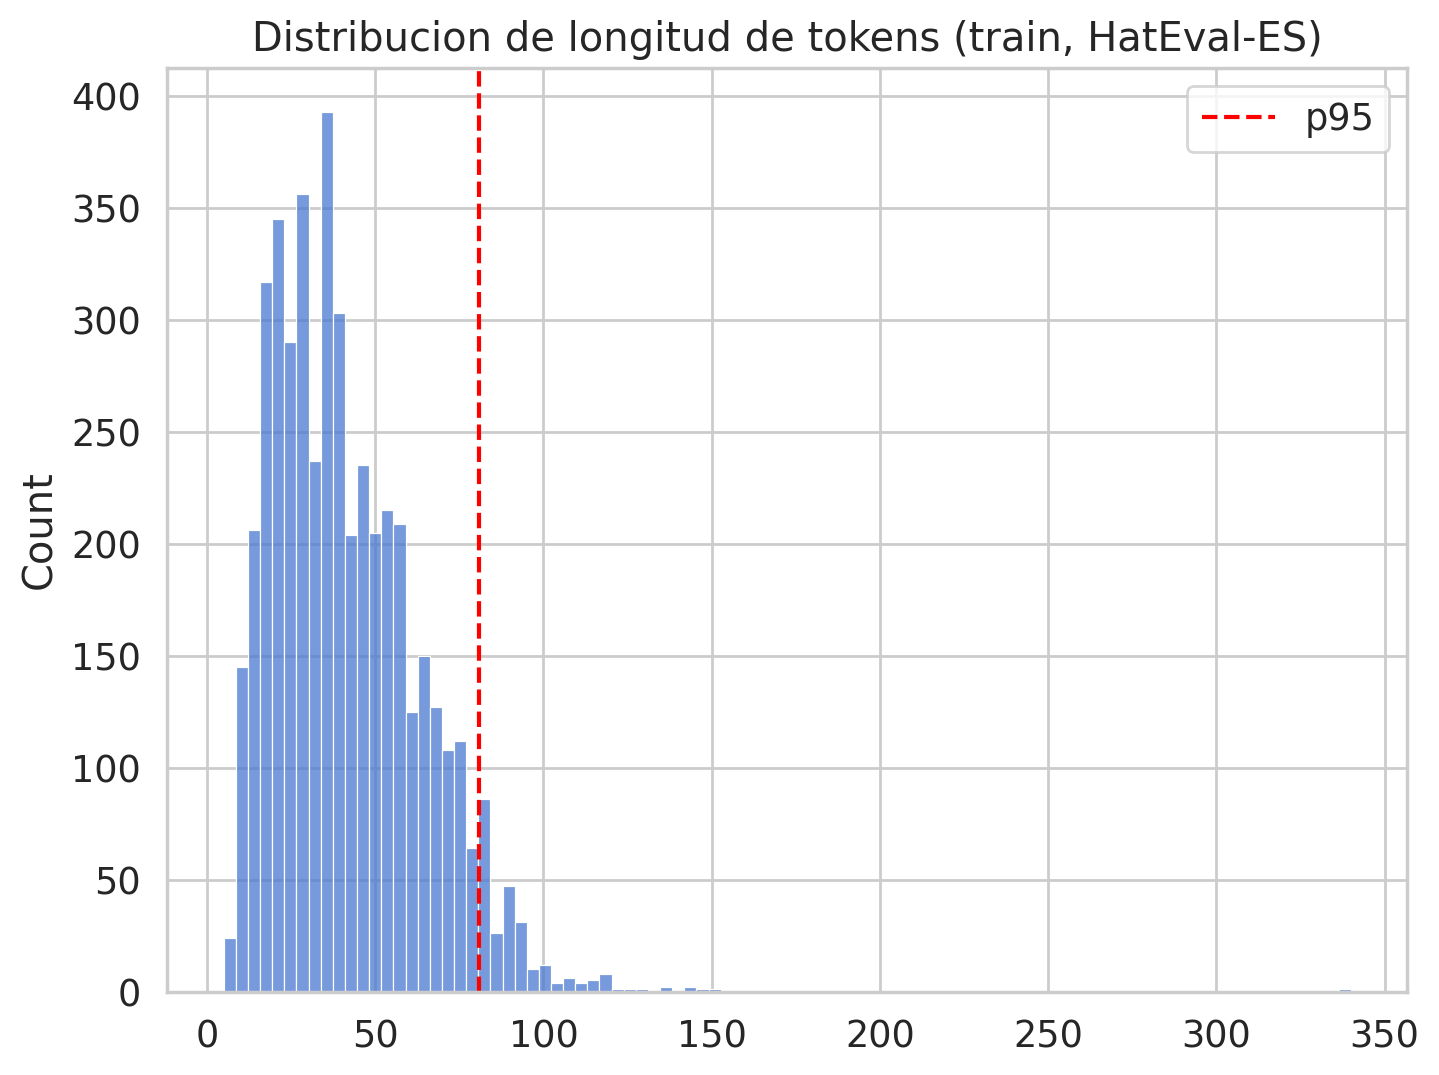

In [12]:
token_counts = np.array([
    len(tokenizer.encode(t, max_length=512, truncation=True))
    for t in train_df["text"]
])

p95 = np.percentile(token_counts, 95)

print("Min:", token_counts.min(), "| Max:", token_counts.max(), "| Media:", token_counts.mean())
print("Percentil 95:", p95)

sns.histplot(token_counts)
plt.axvline(x=p95, color="red", linestyle="--", label="p95")
plt.legend()
plt.title("Distribucion de longitud de tokens (train, HatEval-ES)")
plt.show()

In [13]:
BUCKET = 16
MAX_TOKEN_COUNT = min(512, int(math.ceil(p95 / BUCKET) * BUCKET))

print(f"Percentil 95 real: {p95:.1f} tokens")
print(f"MAX_TOKEN_COUNT seleccionado automaticamente: {MAX_TOKEN_COUNT}")

Percentil 95 real: 81.0 tokens
MAX_TOKEN_COUNT seleccionado automaticamente: 96


## 5. Dataset y DataModule

In [14]:
class HatEvalDataset(Dataset):

    def __init__(self, data: pd.DataFrame, tokenizer: BertTokenizer, max_token_len: int):
        self.tokenizer = tokenizer
        self.data = data.reset_index(drop=True)
        self.max_token_len = max_token_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index: int):
        row = self.data.iloc[index]

        encoding = self.tokenizer.encode_plus(
            row.text,
            add_special_tokens=True,
            max_length=self.max_token_len,
            return_token_type_ids=False,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )

        return dict(
            input_ids=encoding["input_ids"].flatten(),
            attention_mask=encoding["attention_mask"].flatten(),
            label=torch.tensor(row.HS, dtype=torch.long),
        )

In [15]:
class HatEvalDataModule(pl.LightningDataModule):

    def __init__(self, train_df, val_df, test_df, tokenizer, batch_size, max_token_len):
        super().__init__()
        self.batch_size = batch_size
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.tokenizer = tokenizer
        self.max_token_len = max_token_len

    def setup(self, stage=None):
        self.train_dataset = HatEvalDataset(self.train_df, self.tokenizer, self.max_token_len)
        self.val_dataset = HatEvalDataset(self.val_df, self.tokenizer, self.max_token_len)
        self.test_dataset = HatEvalDataset(self.test_df, self.tokenizer, self.max_token_len)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, num_workers=2)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, num_workers=2)

## 6. Modelo: BETO con congelamiento configurable de capas

Se usa *mean pooling* ponderado por `attention_mask` (no `pooler_output`), y el congelamiento de capas se calcula desde el `%` en vez de hardcodearse.

In [16]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def n_layers_to_unfreeze(unfrozen_pct: int, total_layers: int = 12) -> int:
    return round(total_layers * unfrozen_pct / 100)


def apply_freeze_schedule(bert_model: BertModel, unfrozen_pct: int, total_layers: int = 12):
    n_unfrozen = n_layers_to_unfreeze(unfrozen_pct, total_layers)
    n_frozen = total_layers - n_unfrozen

    for param in bert_model.embeddings.parameters():
        param.requires_grad = False

    for i, layer in enumerate(bert_model.encoder.layer):
        requires_grad = i >= n_frozen
        for param in layer.parameters():
            param.requires_grad = requires_grad

    return n_frozen, n_unfrozen


for pct in CONFIG["UNFROZEN_PCTS"]:
    print(f"{pct:>4}% descongelado -> {n_layers_to_unfreeze(pct)} capas entrenables, {12 - n_layers_to_unfreeze(pct)} congeladas")

   0% descongelado -> 0 capas entrenables, 12 congeladas
  25% descongelado -> 3 capas entrenables, 9 congeladas
  50% descongelado -> 6 capas entrenables, 6 congeladas
  75% descongelado -> 9 capas entrenables, 3 congeladas
 100% descongelado -> 12 capas entrenables, 0 congeladas


In [17]:
class BETOHateClassifier(pl.LightningModule):

    def __init__(self, unfrozen_pct: int, class_weights=None,
                 n_training_steps=None, n_warmup_steps=None, lr: float = 2e-5, weight_decay: float = 0.01):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])

        self.bert = BertModel.from_pretrained(CONFIG["BERT_MODEL"], return_dict=True)
        self.n_frozen, self.n_unfrozen = apply_freeze_schedule(self.bert, unfrozen_pct)

        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 2)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)

        self.n_training_steps = n_training_steps
        self.n_warmup_steps = n_warmup_steps
        self.lr = lr
        self.weight_decay = weight_decay

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.bert(input_ids, attention_mask=attention_mask)
        pooled = mean_pooling(output.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = self.criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        return loss, probs

    def training_step(self, batch, batch_idx):
        loss, _ = self(batch["input_ids"], batch["attention_mask"], batch["label"])
        self.log("train_loss", loss, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, probs = self(batch["input_ids"], batch["attention_mask"], batch["label"])
        preds = torch.argmax(probs, dim=1)
        acc = (preds == batch["label"]).float().mean()
        self.log("val_loss", loss, prog_bar=True, logger=True)
        self.log("val_acc", acc, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        trainable_params = [p for p in self.parameters() if p.requires_grad]
        optimizer = AdamW(trainable_params, lr=self.lr, weight_decay=self.weight_decay)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=self.n_warmup_steps, num_training_steps=self.n_training_steps
        )
        return dict(optimizer=optimizer, lr_scheduler=dict(scheduler=scheduler, interval="step"))

    def get_embedding(self, input_ids, attention_mask):
        with torch.no_grad():
            output = self.bert(input_ids, attention_mask=attention_mask)
            return mean_pooling(output.last_hidden_state, attention_mask)

## 7. Ablation study: descongelamiento progresivo (0/25/50/75/100%)

In [18]:
data_module = HatEvalDataModule(
    train_df, val_df, test_df, tokenizer,
    batch_size=CONFIG["BATCH_SIZE"],
    max_token_len=MAX_TOKEN_COUNT
)
data_module.setup()

steps_per_epoch = max(1, len(train_df) // CONFIG["BATCH_SIZE"])
total_training_steps = steps_per_epoch * CONFIG["N_EPOCHS_ABLATION"]
warmup_steps = max(1, total_training_steps // 5)

class_counts = train_df["HS"].value_counts().sort_index()
class_weights = torch.tensor((len(train_df) / (2 * class_counts)).values, dtype=torch.float)

print("Pasos por epoca:", steps_per_epoch)
print("Pasos totales por corrida:", total_training_steps)
print("Class weights (no odio, odio):", class_weights.tolist())

Pasos por epoca: 72
Pasos totales por corrida: 864
Class weights (no odio, odio): [0.8547372221946716, 1.204746961593628]


In [19]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [20]:
ablation_results = []

for pct in CONFIG["UNFROZEN_PCTS"]:
    print(f"\n{'='*20} unfrozen_pct = {pct}% {'='*20}")

    model = BETOHateClassifier(
        unfrozen_pct=pct,
        class_weights=class_weights,
        n_training_steps=total_training_steps,
        n_warmup_steps=warmup_steps,
    )

    logger = CSVLogger(save_dir=str(CONFIG["LOGS_DIR"]), name=f"unfrozen_{pct}pct")
    checkpoint_callback = ModelCheckpoint(save_top_k=1, monitor="val_loss", mode="min", verbose=False)
    early_stopping_callback = EarlyStopping(monitor="val_loss", patience=CONFIG["PATIENCE_ABLATION"], mode="min")

    trainer = pl.Trainer(
        logger=logger,
        callbacks=[checkpoint_callback, early_stopping_callback],
        max_epochs=CONFIG["N_EPOCHS_ABLATION"],
        accelerator="auto",
        devices=[1],
        precision="bf16-mixed",
        log_every_n_steps=20,
        enable_progress_bar=True,
    )

    trainer.fit(model, data_module)

    best_val_loss = checkpoint_callback.best_model_score.item() if checkpoint_callback.best_model_score is not None else None

    ablation_results.append({
        "unfrozen_pct": pct,
        "n_frozen_layers": model.n_frozen,
        "n_unfrozen_layers": model.n_unfrozen,
        "best_val_loss": best_val_loss,
        "best_ckpt_path": checkpoint_callback.best_model_path,
        "stopped_epoch": trainer.current_epoch,
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df


==================== unfrozen_pct = 0% ====================


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA H200') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matm

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ bert       │ BertModel        │  109 M │ eval  │     0 │
│ 1 │ dropout    │ Dropout          │      0 │ train │     0 │
│ 2 │ classifier │ Linear           │  1.5 K │ train │     0 │
│ 3 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 592 K                                                                                            
Non-trainable params: 109 M                                                                                        
Total params: 109 M                                                                                                
Total estimated model params size (MB): 439.410                                                                    
Modules in train mode: 3                                                                                           
Modules in eval mode: 228                                                                                          
Total FLOPs: 0

Output()

...

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ bert       │ BertModel        │  109 M │ eval  │     0 │
│ 1 │ dropout    │ Dropout          │      0 │ train │     0 │
│ 2 │ classifier │ Linear           │  1.5 K │ train │     0 │
│ 3 │ criterion  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 85.6 M                                                                                           
Non-trainable params: 24.2 M                                                                                       
Total params: 109 M                                                                                                
Total estimated model params size (MB): 439.410                                                                    
Modules in train mode: 3                                                                                           
Modules in eval mode: 228                                                                                          
Total FLOPs: 0

Output()

,unfrozen_pct,n_frozen_layers,n_unfrozen_layers,best_val_loss,best_ckpt_path,stopped_epoch
0,0,12,0,0.676754,logs-beto-hateval-ablation/unfrozen_0pct/versi...,12
1,25,9,3,0.434262,logs-beto-hateval-ablation/unfrozen_25pct/vers...,6
2,50,6,6,0.419477,logs-beto-hateval-ablation/unfrozen_50pct/vers...,5
3,75,3,9,0.429347,logs-beto-hateval-ablation/unfrozen_75pct/vers...,5
4,100,0,12,0.411122,logs-beto-hateval-ablation/unfrozen_100pct/ver...,5


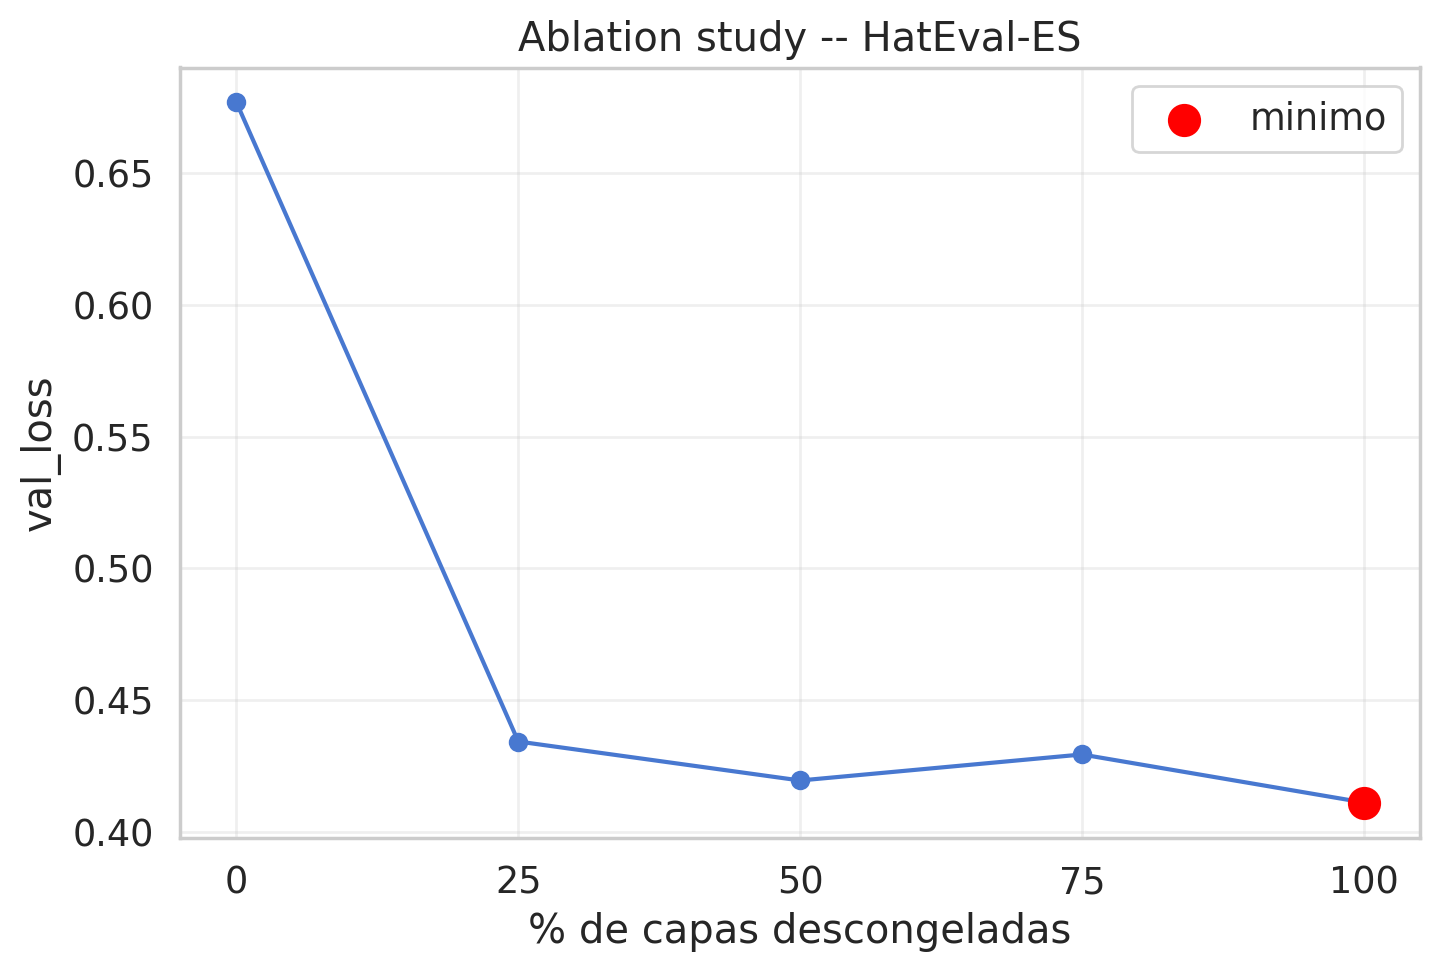

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["unfrozen_pct"], ablation_df["best_val_loss"], marker="o")
best_point = ablation_df.loc[ablation_df["best_val_loss"].idxmin()]
plt.scatter([best_point["unfrozen_pct"]], [best_point["best_val_loss"]], color="red", s=120, zorder=5, label="minimo")
plt.xlabel("% de capas descongeladas")
plt.ylabel("val_loss")
plt.title("Ablation study -- HatEval-ES")
plt.xticks(CONFIG["UNFROZEN_PCTS"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Lectura del ablation study**: `val_loss` cayo de 0.677 con 0% descongelado -- practicamente identico al azar de `ln(2)=0.693`, esperado dado que solo la cabeza lineal es entrenable -- a un rango mucho mas bajo (0.41-0.43) en las cuatro configuraciones descongeladas. El minimo se obtuvo en 100% (0.411), con 50% (0.419) y 75% (0.429) cerca pero no empatados. La curva se despega claramente del azar apenas se descongela una fraccion del *encoder*, y se mantiene estable entre 25% y 100% -- consistente con que, superado un umbral moderado de adaptacion, el nivel exacto de congelamiento tiene un efecto secundario frente al hecho de descongelar *algo*.

## 8. Seleccion automatica del mejor checkpoint

In [22]:
best_row = ablation_df.loc[ablation_df["best_val_loss"].idxmin()]
BEST_UNFROZEN_PCT = int(best_row["unfrozen_pct"])
BEST_CKPT_PATH = best_row["best_ckpt_path"]

print(f"Mejor configuracion: {BEST_UNFROZEN_PCT}% descongelado, val_loss={best_row['best_val_loss']:.4f}")

best_model = BETOHateClassifier.load_from_checkpoint(BEST_CKPT_PATH, class_weights=class_weights)
best_model.eval()
best_model.freeze()

Mejor configuracion: 100% descongelado, val_loss=0.4111


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BETOHateClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31002, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

**Evolucion de `train_loss`/`val_loss` por epoca para la configuracion ganadora.** La ruta se deriva automaticamente de `BEST_CKPT_PATH`, sin necesidad de buscar manualmente la carpeta `version_X` correspondiente.

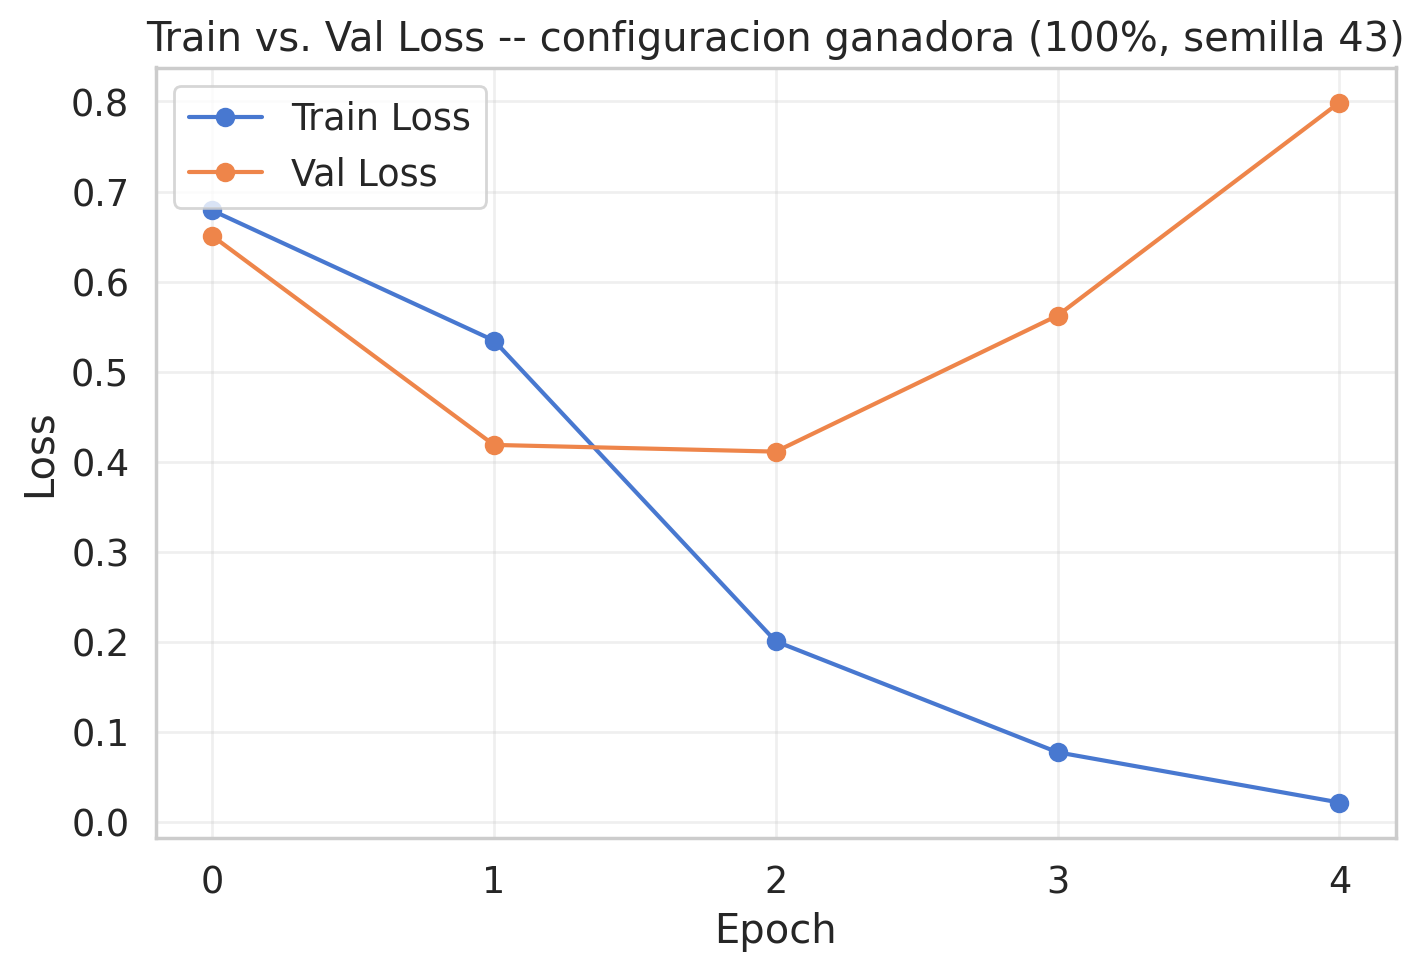

In [23]:
import os
import pandas as pd

metrics_path = os.path.join(os.path.dirname(os.path.dirname(BEST_CKPT_PATH)), "metrics.csv")
metrics_df = pd.read_csv(metrics_path)

train_loss = metrics_df.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].mean()
val_loss = metrics_df.dropna(subset=["val_loss"]).groupby("epoch")["val_loss"].mean()

plt.figure(figsize=(8, 5))
plt.plot(train_loss.index, train_loss.values, label="Train Loss", marker="o")
plt.plot(val_loss.index, val_loss.values, label="Val Loss", marker="o")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Train vs. Val Loss -- configuracion ganadora ({BEST_UNFROZEN_PCT}%, semilla {RANDOM_SEED})")
plt.xticks(train_loss.index.astype(int))
plt.grid(True, alpha=0.3)
plt.show()

## 9. Extraccion de embeddings -- BETO fine-tuneado vs. BETO puro (baseline)

Se extraen embeddings con **dos** modelos sobre exactamente el mismo `test` set: el BETO fine-tuneado (ganador del ablation) y un BETO puro sin ningun entrenamiento adicional (mismo mean pooling). Esta comparacion directa, sobre los mismos datos, es la que responde la pregunta central del proyecto.

In [24]:
def extract_embeddings(model, dataframe, tokenizer, max_token_len, batch_size=32):
    dataset = HatEvalDataset(dataframe, tokenizer, max_token_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    device = next(model.parameters()).device
    embeddings = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            emb = model.get_embedding(input_ids, attention_mask)
            embeddings.append(emb.cpu().numpy())
    return np.vstack(embeddings)


pure_beto = BertModel.from_pretrained(CONFIG["BERT_MODEL"], return_dict=True).eval()

class PureBETOWrapper:
    def __init__(self, bert_model):
        self.bert_model = bert_model
    def parameters(self):
        return self.bert_model.parameters()
    def get_embedding(self, input_ids, attention_mask):
        with torch.no_grad():
            output = self.bert_model(input_ids, attention_mask=attention_mask)
            return mean_pooling(output.last_hidden_state, attention_mask)

pure_wrapper = PureBETOWrapper(pure_beto)

embeddings_by_source = {}
for source, model_obj in [("finetuned", best_model), ("pure_beto", pure_wrapper)]:
    embeddings_by_source[source] = {
        "X_train": extract_embeddings(model_obj, train_df, tokenizer, MAX_TOKEN_COUNT),
        "X_val":   extract_embeddings(model_obj, val_df, tokenizer, MAX_TOKEN_COUNT),
        "X_test":  extract_embeddings(model_obj, test_df, tokenizer, MAX_TOKEN_COUNT),
    }
    np.save(CONFIG["EMBEDDINGS_DIR"] / f"X_train_{source}.npy", embeddings_by_source[source]["X_train"])
    np.save(CONFIG["EMBEDDINGS_DIR"] / f"X_test_{source}.npy", embeddings_by_source[source]["X_test"])
    print(source, "->", embeddings_by_source[source]["X_train"].shape)

y_train = train_df["HS"].values
y_val = val_df["HS"].values
y_test = test_df["HS"].values

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


finetuned -> (4619, 768)
pure_beto -> (4619, 768)


## 10. Clasificador clasico -- comparacion BETO fine-tuneado vs. BETO puro

In [25]:
cv = RepeatedStratifiedKFold(n_splits=CONFIG["CV_FOLDS"], n_repeats=CONFIG["CV_REPEATS"], random_state=CONFIG["RANDOM_STATE"])

classifiers_template = {
    "LR": lambda: LogisticRegression(class_weight="balanced", max_iter=1000, random_state=CONFIG["RANDOM_STATE"]),
    "SVM": lambda: SVC(kernel="rbf", class_weight="balanced", random_state=CONFIG["RANDOM_STATE"]),
    "RF": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=CONFIG["RANDOM_STATE"]),
    "GradientBoosting": lambda: GradientBoostingClassifier(random_state=CONFIG["RANDOM_STATE"]),
}

cv_results = []
for source in ["pure_beto", "finetuned"]:
    X_train_full = np.vstack([embeddings_by_source[source]["X_train"], embeddings_by_source[source]["X_val"]])
    y_train_full = np.concatenate([y_train, y_val])

    for name, clf_fn in classifiers_template.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf_fn())])
        scores = cross_validate(pipe, X_train_full, y_train_full, cv=cv, scoring=["f1", "f1_weighted"], n_jobs=-1)
        cv_results.append({
            "Embedding": source,
            "Modelo": name,
            "F1": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
            "F1 weighted": f"{scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}",
            "F1_mean": scores["test_f1"].mean(),
        })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.drop(columns="F1_mean")

,Embedding,Modelo,F1,F1 weighted
0,pure_beto,LR,0.6838 ± 0.0155,0.7299 ± 0.0122
1,pure_beto,SVM,0.7347 ± 0.0134,0.7757 ± 0.0101
2,pure_beto,RF,0.5374 ± 0.0254,0.6856 ± 0.0142
3,pure_beto,GradientBoosting,0.6395 ± 0.0226,0.7259 ± 0.0154
4,finetuned,LR,0.9188 ± 0.0102,0.9325 ± 0.0084
5,finetuned,SVM,0.9446 ± 0.0061,0.9540 ± 0.0052
6,finetuned,RF,0.9438 ± 0.0055,0.9537 ± 0.0045
7,finetuned,GradientBoosting,0.9425 ± 0.0070,0.9524 ± 0.0059


**Lectura de la comparacion de validacion cruzada**: el fine-tuning (`finetuned`) supera a `pure_beto` en las 4 familias de clasificadores, sin excepcion: Regresion Logistica pasa de F1=0.684 a 0.919 (+0.235), SVM de 0.735 a 0.945 (+0.210), Random Forest de 0.537 a 0.944 (+0.406), y Gradient Boosting de 0.640 a 0.943 (+0.303). La ganancia es sistematica y de gran magnitud en las cuatro familias -- muy por encima de cualquier variacion atribuible a ruido de muestreo -- confirmando que el *fine-tuning* mejora la calidad del embedding de forma general, no solo para el clasificador que mejor lo aprovecha.

Mejor combinacion: embeddings de 'finetuned' + clasificador 'SVM'


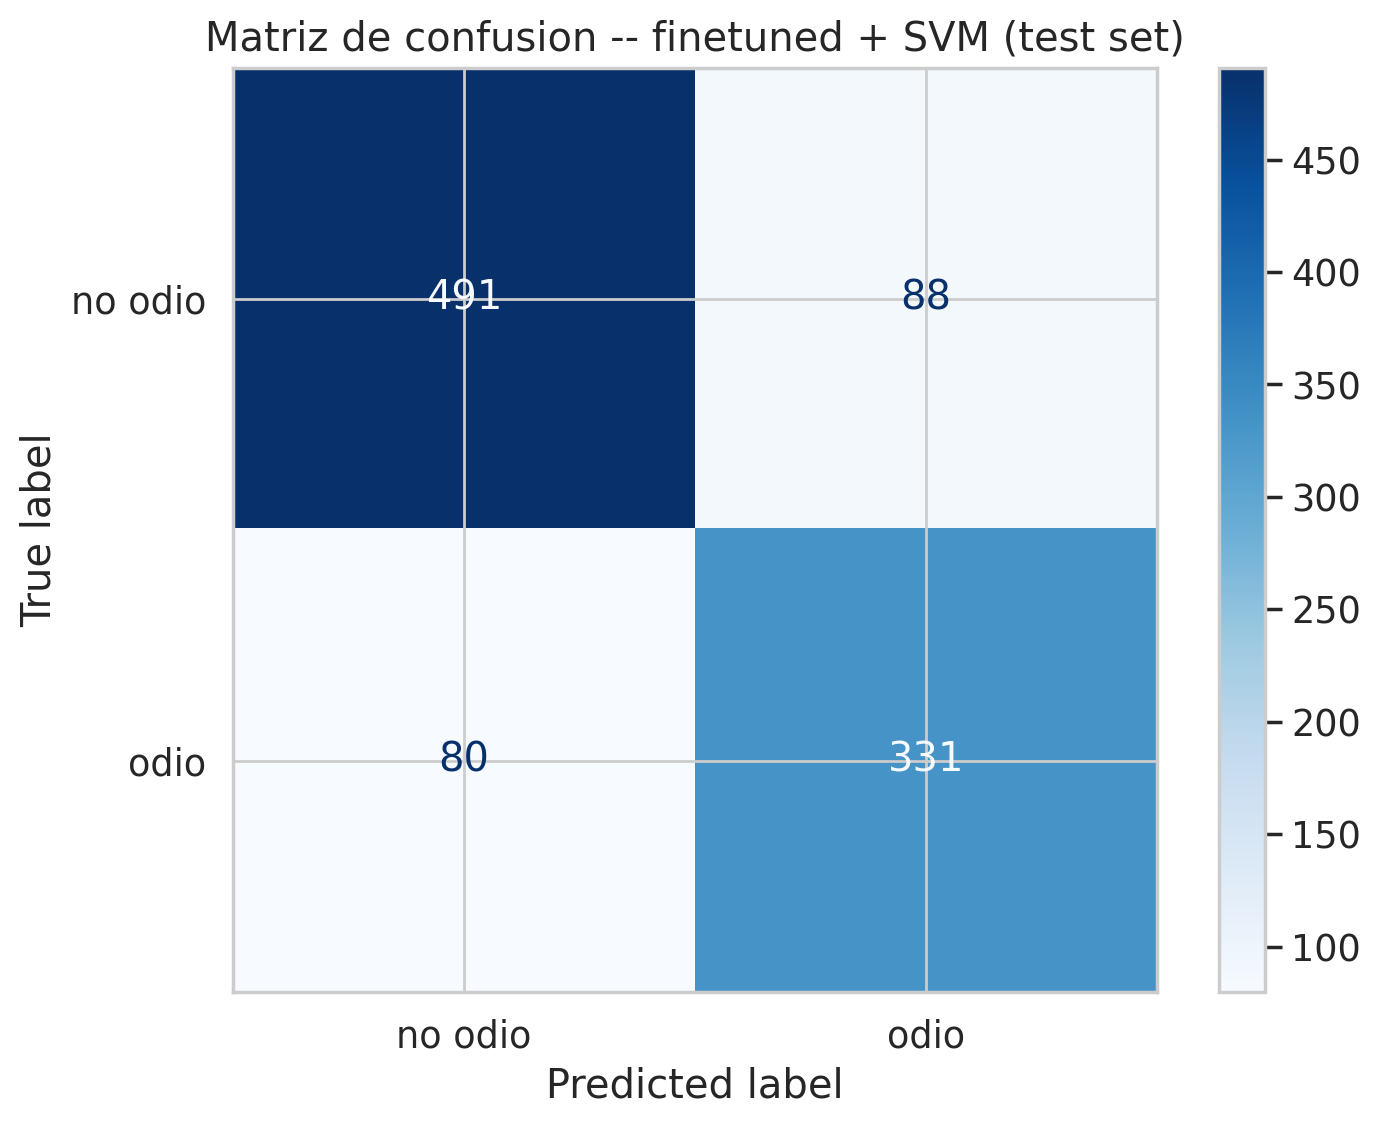

              precision    recall  f1-score   support

     no odio       0.86      0.85      0.85       579
        odio       0.79      0.81      0.80       411

    accuracy                           0.83       990
   macro avg       0.82      0.83      0.83       990
weighted avg       0.83      0.83      0.83       990



In [26]:
best_row_overall = cv_results_df.loc[cv_results_df["F1_mean"].idxmax()]
best_source = best_row_overall["Embedding"]
best_clf_name = best_row_overall["Modelo"]

print(f"Mejor combinacion: embeddings de '{best_source}' + clasificador '{best_clf_name}'")

X_train_full_best = np.vstack([embeddings_by_source[best_source]["X_train"], embeddings_by_source[best_source]["X_val"]])
y_train_full = np.concatenate([y_train, y_val])
X_test_best = embeddings_by_source[best_source]["X_test"]

final_pipe = Pipeline([("scaler", StandardScaler()), ("clf", classifiers_template[best_clf_name]())])
final_pipe.fit(X_train_full_best, y_train_full)
y_pred_test = final_pipe.predict(X_test_best)

cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no odio", "odio"]).plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusion -- {best_source} + {best_clf_name} (test set)")
plt.show()

print(classification_report(y_test, y_pred_test, target_names=["no odio", "odio"]))

In [27]:
acc = accuracy_score(y_test, y_pred_test)
n = len(y_test)
se = math.sqrt(acc * (1 - acc) / n)
ci_95 = 1.96 * se

print(f"Accuracy en test: {acc:.4f}  (n={n})")
print(f"Intervalo de confianza 95%: [{acc - ci_95:.4f}, {acc + ci_95:.4f}]")

Accuracy en test: 0.8303  (n=990)
Intervalo de confianza 95%: [0.8069, 0.8537]


## 11. t-SNE -- comparacion visual y cuantitativa contra el baseline

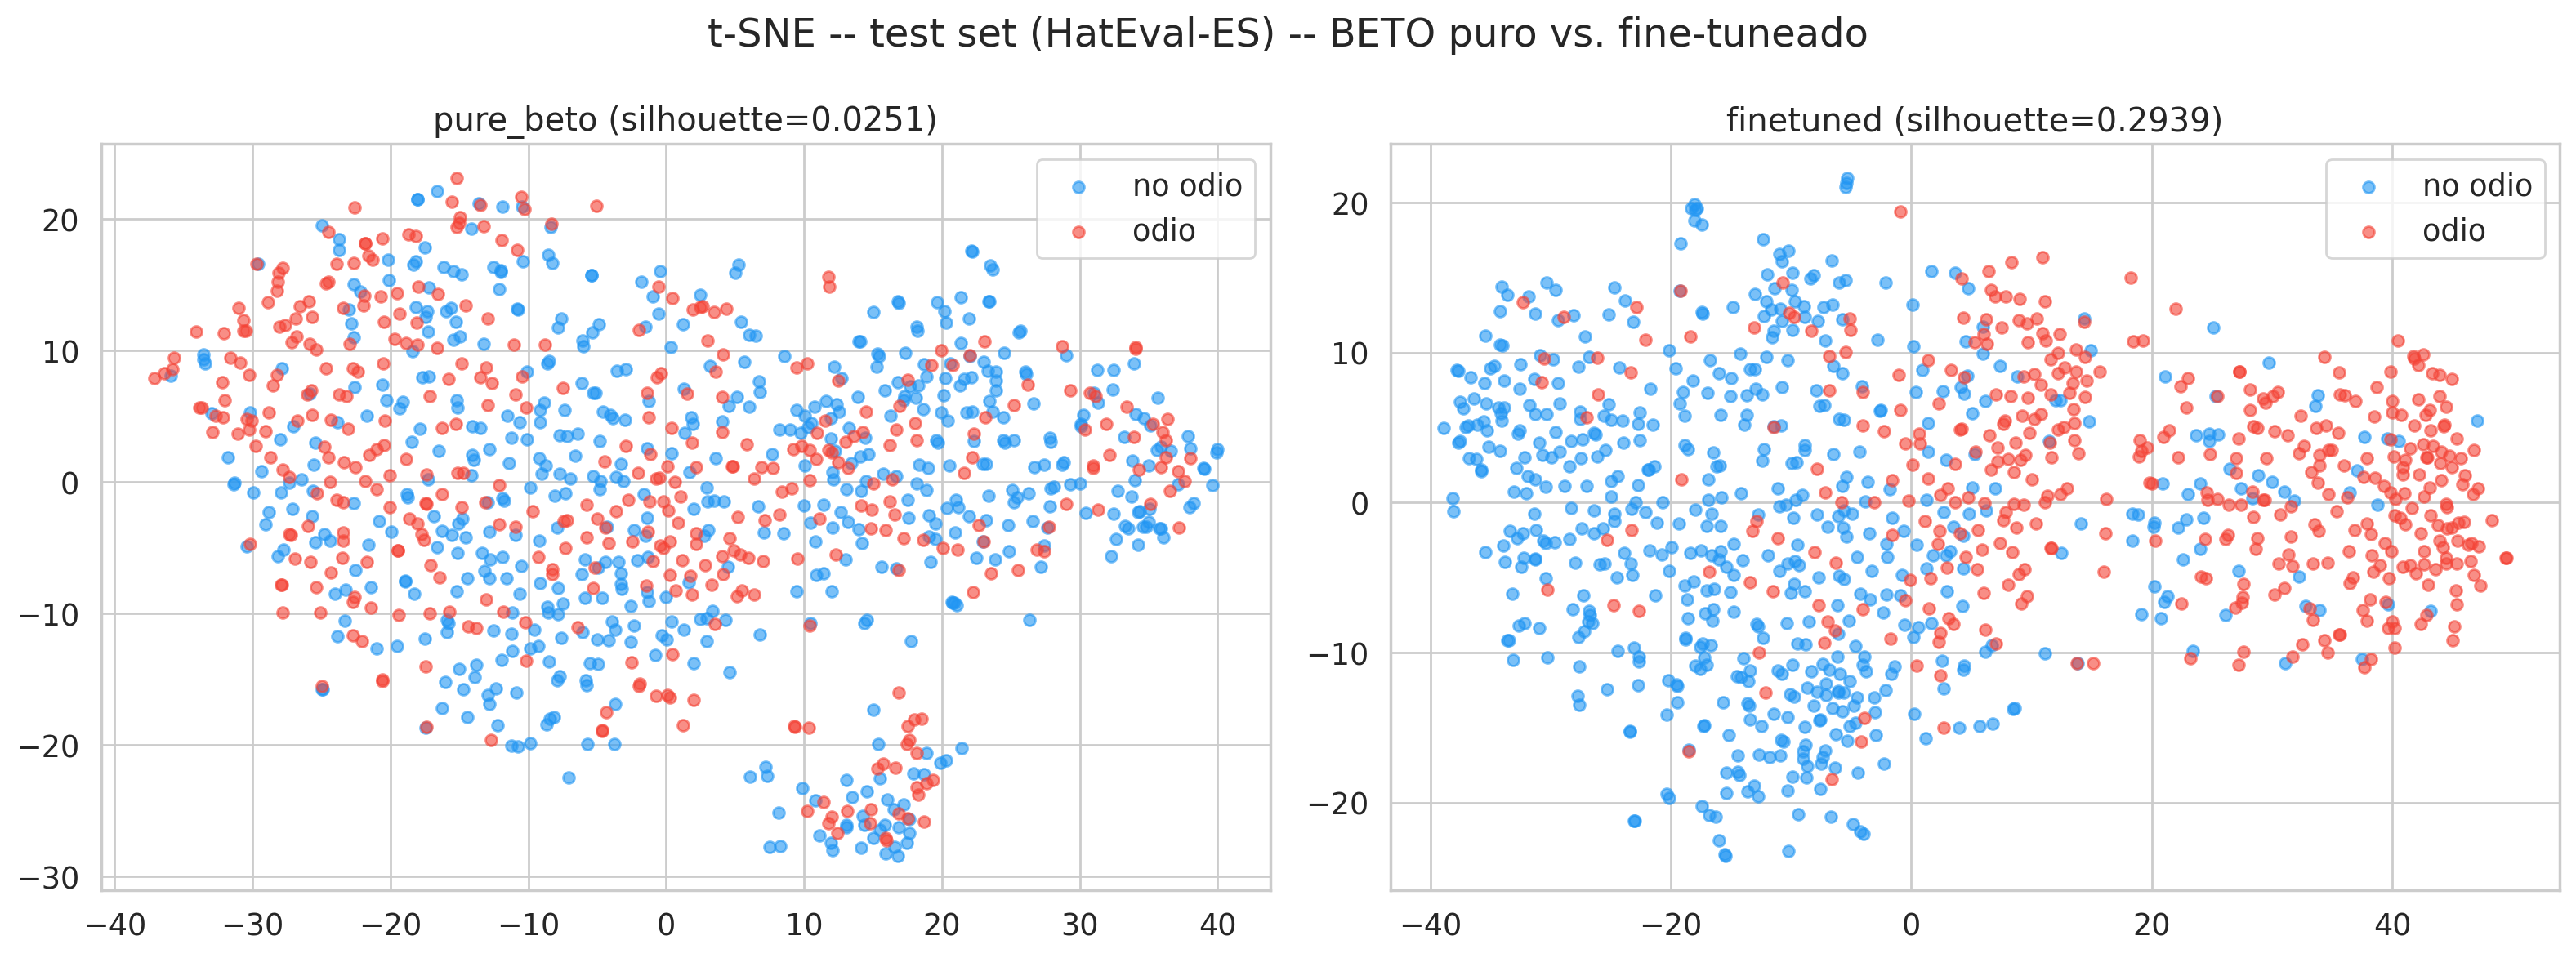

Silhouette, BETO puro: 0.0251
Silhouette, BETO fine-tuneado: 0.2939


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {0: "#2196F3", 1: "#F44336"}
labels_name = {0: "no odio", 1: "odio"}
silhouettes = {}

for ax, source in zip(axes, ["pure_beto", "finetuned"]):
    X_test_source = embeddings_by_source[source]["X_test"]
    tsne = TSNE(n_components=2, random_state=CONFIG["RANDOM_STATE"], perplexity=min(30, len(X_test_source) - 1))
    X_2d = tsne.fit_transform(X_test_source)

    for label, color in palette.items():
        mask = y_test == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=labels_name[label], alpha=0.6, s=25)
    sil = silhouette_score(X_2d, y_test)
    silhouettes[source] = sil
    ax.set_title(f"{source} (silhouette={sil:.4f})")
    ax.legend()

plt.suptitle("t-SNE -- test set (HatEval-ES) -- BETO puro vs. fine-tuneado")
plt.tight_layout()
plt.show()

print("Silhouette, BETO puro:", round(silhouettes["pure_beto"], 4))
print("Silhouette, BETO fine-tuneado:", round(silhouettes["finetuned"], 4))

**Lectura de la comparacion t-SNE/silhouette**: el *silhouette score* del conjunto de prueba pasa de 0.025 (BETO puro) a 0.294 (BETO ajustado) -- un salto de un orden de magnitud, visible directamente en la proyeccion: BETO puro muestra las clases completamente entremezcladas, mientras que BETO ajustado exhibe regiones claramente dominadas por cada clase (aunque sin separacion perfecta). Esta es la evidencia central del proyecto: el *fine-tuning* con una senal supervisada reorganiza el espacio de embeddings hacia el constructo objetivo, medible con una metrica geometrica independiente de cualquier clasificador posterior.

## 12. Conclusiones y Discusion

### Resultados obtenidos

El *ablation study* confirmo que el *fine-tuning* con HatEval-ES aprende senal real y consistente: `val_loss` cayo de 0.677 (0% descongelado, practicamente el baseline de azar `ln(2)=0.693`) a un rango bajo y estable entre 0.41 y 0.43 en las cuatro configuraciones descongeladas, con el minimo en 100% (0.411).

La comparacion de validacion cruzada entre BETO puro y BETO fine-tuneado, sobre las cuatro familias de clasificadores clasicos, mostro una mejora sistematica y de gran magnitud: Regresion Logistica paso de F1=0.684 a 0.919 (+0.235), SVM de 0.735 a 0.945 (+0.210), Random Forest de 0.537 a 0.944 (+0.406), y Gradient Boosting de 0.640 a 0.943 (+0.303). Ningun clasificador quedo sin mejorar.

En el conjunto de prueba, la mejor combinacion (embeddings fine-tuneados + SVM) alcanzo un *accuracy* de 0.8303 (IC 95%: [0.8069, 0.8537], n=990), con F1 macro de 0.83 (f1-score de 0.85 para `no odio` y 0.80 para `odio`), muy por encima de la linea base de predecir siempre la clase mayoritaria (0.585). El *silhouette score* en test confirmo la mejora tambien en el espacio geometrico: 0.025 con BETO puro frente a 0.294 con BETO fine-tuneado.

### Comparacion con el estado del arte de 2019

El mejor resultado reportado en el *subtask* A para espanol del *shared task* original (Basile et al., 2019) fue F1 macro=0.730, alcanzado de forma empatada por los equipos mineriaUNAM, Atalaya y MITRE (de 35 sistemas validos presentados). El modelo de este trabajo alcanza F1 macro=0.83 en prueba, superando ese maximo historico en +0.10 puntos absolutos (+13.7% relativo) -- una diferencia consistente con la brecha tecnologica de seis anos entre ambos trabajos: los sistemas de 2019 se basaban predominantemente en SVM, LSTM y CNN sobre embeddings estaticos (GloVe, FastText), mientras que BERT, publicado apenas meses antes del *shared task*, aun no habia sido adoptado ampliamente por los participantes.

### Interpretacion del patron 0% vs. 25-100%

La brecha entre 0% y el resto no es gradual sino un salto: con el *encoder* completamente congelado, la unica adaptacion posible es una transformacion lineal sobre un embedding no orientado a la tarea -- una limitacion estructuralmente equivalente a la observada con Regresion Logistica sobre BETO puro (F1=0.684). La literatura sobre la estructura interna de BERT (Jawahar et al., 2019) indica que sus capas superiores concentran informacion semantica de mas alto nivel, mientras las capas inferiores capturan sintaxis y lexico generico, mas transferible entre tareas. Descongelar el 25% superior ya da acceso a la porcion del *encoder* mas relevante para la tarea, capturando la mayor parte de la ganancia alcanzable.

Una observacion adicional de interes: Random Forest sobre embeddings de BETO puro rindio notablemente peor (F1=0.537) que los otros tres clasificadores con el mismo embedding, pero con embeddings fine-tuneados alcanzo F1=0.944, practicamente empatado con SVM (0.945). Esto sugiere que el *fine-tuning* no solo mejora la calidad general del embedding, sino que tambien lo hace mas favorable para una gama mas amplia de clasificadores posteriores, no unicamente para el de mejor desempeno individual.

### Nota sobre robustez frente a la semilla aleatoria

Esta corrida especifica uso `RANDOM_SEED=43`. En el marco del proyecto completo (documentado en el paper que acompana este notebook), se repitio el mismo *pipeline* con una semilla adicional (44): en las dos corridas, la configuracion optima exacta del *ablation* varió (43 favorecen 100%, 44 favorece 75%, con valores de `val_loss` siempre dentro de un rango estrecho entre las configuraciones descongeladas), pero la magnitud de la mejora del *fine-tuning* frente a BETO puro se mantuvo consistente en las dos semillas (accuracy de prueba entre 0.83 y 0.84; silhouette del embedding ajustado entre 0.29 y 0.30). Esto indica que la configuracion de congelamiento optima es sensible a la inicializacion aleatoria, pero la mejora central del trabajo no lo es.

### Limitaciones

- El *dataset* fue recolectado en 2018-2019; el lenguaje de odio en redes sociales evoluciona, por lo que el desempeno reportado podria no generalizar a contenido actual.
- El alcance se limita a dos objetivos de odio (mujeres e inmigrantes), sin evaluar generalizacion a otras formas de discurso de odio.
- La configuracion optima exacta del *ablation* de congelamiento no es estable entre semillas aleatorias, por lo que no debe interpretarse como una recomendacion prescriptiva de un porcentaje especifico, sino como evidencia de que descongelar al menos una fraccion moderada del modelo es suficiente.

### Trabajo futuro

- Incorporar las subtareas `TR` y `AG` sobre el subconjunto de tweets ya identificados como odiosos.
- Evaluar el modelo ajustado sobre datos mas recientes para estimar su vigencia temporal.